In [ ]:
import pandas as pd
import numpy as np

# Load the dataset from the Excel file
df_processed = pd.read_excel('/content/Full Data.xlsx')

print("Original DataFrame head:")
display(df_processed.head())
print("Original DataFrame info:")
display(df_processed.info())

Original DataFrame head:


,Date,Time,Date & Time,Bottom Hole Pressure,Corrected Bottom Hole Pressure,Bottom Hole Temperature,Surface Temperature,Surface PSI,Annulus PSI,Flowrate meter,Pump Speed,Calc. Flow from Pump Speed,Flow BPM,Temperature before Triplex,Pressure before Triplex
0,2009-09-19,12:40:42,2009-09-19 12:40:42,6.967,6.967,89.467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-09-19,12:40:52,2009-09-19 12:40:52,8.194,8.194,89.485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-09-19,12:41:02,2009-09-19 12:41:02,8.511,8.511,89.501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-09-19,12:41:12,2009-09-19 12:41:12,8.509,8.509,89.518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-09-19,12:41:22,2009-09-19 12:41:22,8.510,8.510,89.537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Original DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61867 entries, 0 to 61866
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   Date                            61867 non-null  datetime64[ns]
 1   Time                            61867 non-null  object        
 2   Date & Time                     61867 non-null  datetime64[ns]
 3   Bottom Hole Pressure            61866 non-null  float64       
 4   Corrected Bottom Hole Pressure  61776 non-null  float64       
 5   Bottom Hole Temperature         61866 non-null  float64       
 6   Surface Temperature             12696 non-null  object        
 7   Surface PSI                     12432 non-null  float64       
 8   Annulus PSI                     12432 non-null  float64       
 9   Flowrate meter                  12432 non-null  float64       
 10  Pump Speed                      10080 non-nul

None

## Data Cleaning and Preprocessing based on Operational Context

First, I'll standardize the column names for easier access and ensure the 'Date & Time' column is in the correct datetime format. Then, I'll define the operational periods based on your input to guide missing value imputation.

In [ ]:
# Standardize column names (lowercase, replace spaces with underscores)
df_processed.columns = df_processed.columns.str.lower().str.replace(' ', '_').str.replace('&', '_and_').str.replace('.', '', regex=False).str.replace('/', '_', regex=False)

# Ensure 'date__and__time' is a datetime object
df_processed['date__and__time'] = pd.to_datetime(df_processed['date__and__time'])

# Convert 'surface_temperature' to numeric, coercing errors to NaN
df_processed['surface_temperature'] = pd.to_numeric(df_processed['surface_temperature'], errors='coerce')

print("DataFrame head after column renaming and type conversion:")
display(df_processed.head())

DataFrame head after column renaming and type conversion:


,date,time,date__and__time,bottom_hole_pressure,corrected_bottom_hole_pressure,bottom_hole_temperature,surface_temperature,surface_psi,annulus_psi,flowrate_meter,pump_speed,calc_flow_from_pump_speed,flow_bpm,temperature_before_triplex,pressure_before_triplex
0,2009-09-19,12:40:42,2009-09-19 12:40:42,6.967,6.967,89.467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-09-19,12:40:52,2009-09-19 12:40:52,8.194,8.194,89.485,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-09-19,12:41:02,2009-09-19 12:41:02,8.511,8.511,89.501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-09-19,12:41:12,2009-09-19 12:41:12,8.509,8.509,89.518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-09-19,12:41:22,2009-09-19 12:41:22,8.510,8.510,89.537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Defining Operational Periods and Context-Aware Missing Value Handling

Based on your provided logs, I'll define specific recording and non-recording periods. Missing values in process-related columns will be imputed with 0 during non-recording times, as this signifies no operation. For 'Bottom Hole Pressure' and 'Bottom Hole Temperature', I'll use interpolation for small gaps within recording periods. Values during the 'flowmeter did not work' period will also be handled specifically for flow-related columns.

In [ ]:
# Define operational periods as provided by the user
recording_period_1_start = pd.to_datetime('2009-09-20 07:34:53')
recording_period_1_end = pd.to_datetime('2009-09-20 16:59:15')

recording_period_2_start = pd.to_datetime('2009-09-21 17:33:11') # Flowmeter did not work
recording_period_2_end = pd.to_datetime('2009-09-22 00:58:09')

recording_period_3_start = pd.to_datetime('2009-09-24 19:40:25')
recording_period_3_end = pd.to_datetime('2009-09-25 07:42:45')

# Create a mask for all active recording periods
df_processed['is_recording'] = (
    ((df_processed['date__and__time'] >= recording_period_1_start) & (df_processed['date__and__time'] <= recording_period_1_end)) |
    ((df_processed['date__and__time'] >= recording_period_2_start) & (df_processed['date__and__time'] <= recording_period_2_end)) |
    ((df_processed['date__and__time'] >= recording_period_3_start) & (df_processed['date__and__time'] <= recording_period_3_end))
)

# Create a flag for the flowmeter issue period
df_processed['flowmeter_issue_period'] = (
    (df_processed['date__and__time'] >= recording_period_2_start) & (df_processed['date__and__time'] <= recording_period_2_end)
)

# Columns to be imputed with 0 during non-recording periods
operational_columns = [
    'surface_temperature', 'surface_psi', 'annulus_psi', 'flowrate_meter',
    'pump_speed', 'calc_flow_from_pump_speed', 'flow_bpm', 'temperature_before_triplex', 'pressure_before_triplex'
]

# Impute NaNs with 0 for operational columns outside recording periods
for col in operational_columns:
    if col in df_processed.columns:
        df_processed.loc[~df_processed['is_recording'] & df_processed[col].isnull(), col] = 0

# For flowmeter_meter during the flowmeter_issue_period, set to 0
df_processed.loc[df_processed['flowmeter_issue_period'], 'flowrate_meter'] = 0

# For target variables, impute remaining NaNs (if any) using interpolation within recording periods, otherwise 0
target_cols = ['bottom_hole_pressure', 'corrected_bottom_hole_pressure', 'bottom_hole_temperature']
for col in target_cols:
    if col in df_processed.columns:
        # Interpolate within recording periods
        df_processed.loc[df_processed['is_recording'], col] = df_processed.loc[df_processed['is_recording'], col].interpolate(method='linear')
        # Fill any remaining NaNs (outside recording periods or at edges) with 0
        df_processed[col] = df_processed[col].fillna(0)

# Impute any other remaining NaNs in operational columns (e.g., within recording periods) with 0 or a reasonable value
# For simplicity, let's fill with 0, assuming NaN means 'inactive' or 'not measured' even during some recording times
for col in operational_columns:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].fillna(0)


print("\nDataFrame info after context-aware missing value handling:")
display(df_processed.info())
print("\nRemaining missing values after imputation:")
display(df_processed.isnull().sum()[df_processed.isnull().sum() > 0])
print("\nDataFrame head after imputation:")
display(df_processed.head())


DataFrame info after context-aware missing value handling:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61867 entries, 0 to 61866
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            61867 non-null  datetime64[ns]
 1   time                            61867 non-null  object        
 2   date__and__time                 61867 non-null  datetime64[ns]
 3   bottom_hole_pressure            61867 non-null  float64       
 4   corrected_bottom_hole_pressure  61867 non-null  float64       
 5   bottom_hole_temperature         61867 non-null  float64       
 6   surface_temperature             61867 non-null  float64       
 7   surface_psi                     61867 non-null  float64       
 8   annulus_psi                     61867 non-null  float64       
 9   flowrate_meter                  61867 non-null  float64       
 10  pump_speed

None


Remaining missing values after imputation:


,0



DataFrame head after imputation:


,date,time,date__and__time,bottom_hole_pressure,corrected_bottom_hole_pressure,bottom_hole_temperature,surface_temperature,surface_psi,annulus_psi,flowrate_meter,pump_speed,calc_flow_from_pump_speed,flow_bpm,temperature_before_triplex,pressure_before_triplex,is_recording,flowmeter_issue_period,hour_of_day,day_of_week
0,2009-09-19,12:40:42,2009-09-19 12:40:42,6.967,6.967,89.467,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,12,5
1,2009-09-19,12:40:52,2009-09-19 12:40:52,8.194,8.194,89.485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,12,5
2,2009-09-19,12:41:02,2009-09-19 12:41:02,8.511,8.511,89.501,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,12,5
3,2009-09-19,12:41:12,2009-09-19 12:41:12,8.509,8.509,89.518,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,12,5
4,2009-09-19,12:41:22,2009-09-19 12:41:22,8.510,8.510,89.537,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,False,12,5


## Exploratory Data Analysis (EDA)

Now that the data is cleaned and preprocessed, let's perform some exploratory data analysis to understand the relationships between variables. A correlation heatmap is a great way to visualize these relationships.

### Feature Engineering

Now, I'll extract some time-based features from the 'date_and_time' column that could be useful for machine learning models, such as hour of the day and day of the week.

In [ ]:
# Extract time-based features
df_processed['hour_of_day'] = df_processed['date__and__time'].dt.hour
df_processed['day_of_week'] = df_processed['date__and__time'].dt.dayofweek # Monday=0, Sunday=6

# Display head with new features
print("DataFrame head with new time-based features:")
display(df_processed.head())

print("DataFrame info after feature engineering:")
display(df_processed.info())

DataFrame head with new time-based features:


,date,time,date__and__time,bottom_hole_pressure,corrected_bottom_hole_pressure,bottom_hole_temperature,surface_temperature,surface_psi,annulus_psi,flowrate_meter,pump_speed,calc_flow_from_pump_speed,flow_bpm,temperature_before_triplex,pressure_before_triplex,is_recording,flowmeter_issue_period,hour_of_day,day_of_week
0,2009-09-19,12:40:42,2009-09-19 12:40:42,6.967,6.967,89.467,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,False,False,12,5
1,2009-09-19,12:40:52,2009-09-19 12:40:52,8.194,8.194,89.485,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,False,False,12,5
2,2009-09-19,12:41:02,2009-09-19 12:41:02,8.511,8.511,89.501,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,False,False,12,5
3,2009-09-19,12:41:12,2009-09-19 12:41:12,8.509,8.509,89.518,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,False,False,12,5
4,2009-09-19,12:41:22,2009-09-19 12:41:22,8.510,8.510,89.537,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,False,False,12,5


DataFrame info after feature engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61867 entries, 0 to 61866
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            61867 non-null  datetime64[ns]
 1   time                            61867 non-null  object        
 2   date__and__time                 61867 non-null  datetime64[ns]
 3   bottom_hole_pressure            61867 non-null  float64       
 4   corrected_bottom_hole_pressure  61867 non-null  float64       
 5   bottom_hole_temperature         61867 non-null  float64       
 6   surface_temperature             61867 non-null  float64       
 7   surface_psi                     61867 non-null  float64       
 8   annulus_psi                     61867 non-null  float64       
 9   flowrate_meter                  61867 non-null  float64       
 10  pump_speed                  

None

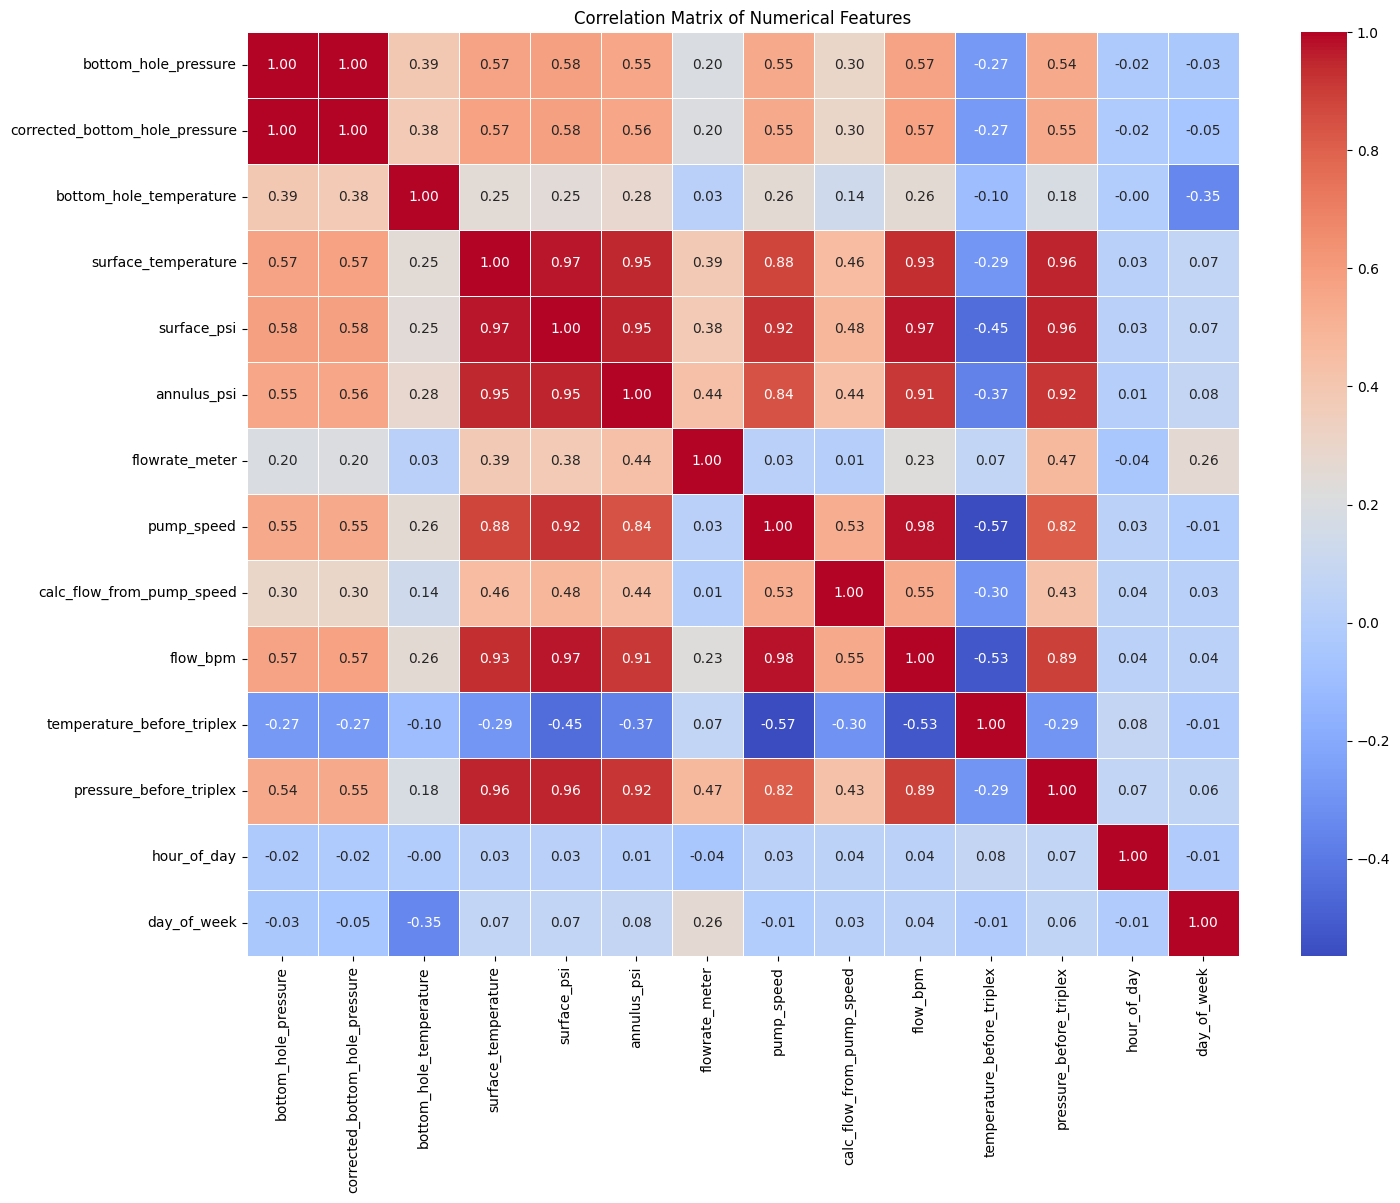

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
# Exclude boolean flags like 'is_recording' and 'flowmeter_issue_period' for a clearer heatmap if desired, or keep them if their correlation with numerical features is relevant.
numerical_df = df_processed.select_dtypes(include=['float64', 'int32'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Plotting the heatmap
plt.figure(figsize=(16, 12)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Machine Learning Model Training and Evaluation

Now, let's prepare the data for machine learning by splitting it into training and testing sets. We will then train various prediction models for 'bottom_hole_pressure' and 'bottom_hole_temperature', evaluate their performance, and select the best performing model. Finally, we'll visualize the differences between predicted and actual data.

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target variables (y)
# Drop 'date', 'time', 'date__and__time', 'is_recording', 'flowmeter_issue_period'
# Also drop 'corrected_bottom_hole_pressure' as it's highly correlated with 'bottom_hole_pressure' and likely a variant of the same target.
# We will treat 'bottom_hole_pressure' and 'bottom_hole_temperature' as separate targets.

X = df_processed.drop(columns=[
    'date', 'time', 'date__and__time',
    'bottom_hole_pressure', 'corrected_bottom_hole_pressure', 'bottom_hole_temperature',
    'is_recording', 'flowmeter_issue_period'
])
y_pressure = df_processed['bottom_hole_pressure']
y_temperature = df_processed['bottom_hole_temperature']

# Split the data into training and testing sets for bottom_hole_pressure
X_train_pressure, X_test_pressure, y_train_pressure, y_test_pressure = train_test_split(
    X, y_pressure, test_size=0.2, random_state=42
)

# Split the data into training and testing sets for bottom_hole_temperature
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X, y_temperature, test_size=0.2, random_state=42
)

print("Shape of X_train_pressure:", X_train_pressure.shape)
print("Shape of y_train_pressure:", y_train_pressure.shape)
print("Shape of X_test_pressure:", X_test_pressure.shape)
print("Shape of y_test_pressure:", y_test_pressure.shape)

print("\nShape of X_train_temp:", X_train_temp.shape)
print("Shape of y_train_temp:", y_train_temp.shape)
print("Shape of X_test_temp:", X_test_temp.shape)
print("Shape of y_test_temp:", y_test_temp.shape)

Shape of X_train_pressure: (49493, 11)
Shape of y_train_pressure: (49493,)
Shape of X_test_pressure: (12374, 11)
Shape of y_test_pressure: (12374,)

Shape of X_train_temp: (49493, 11)
Shape of y_train_temp: (49493,)
Shape of X_test_temp: (12374, 11)
Shape of y_test_temp: (12374,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
}

# --- Predict Bottom Hole Pressure ---
print("\n--- Predicting Bottom Hole Pressure ---")
pressure_results = {}
pressure_predictions = {}

for name, model in models.items():
    print(f"\nTraining {name} for Bottom Hole Pressure...")
    model.fit(X_train_pressure, y_train_pressure)
    y_pred_pressure = model.predict(X_test_pressure)

    mae = mean_absolute_error(y_test_pressure, y_pred_pressure)
    mse = mean_squared_error(y_test_pressure, y_pred_pressure)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_pressure, y_pred_pressure)

    pressure_results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
    pressure_predictions[name] = y_pred_pressure

    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2 Score: {r2:.2f}")

# Select the best model for pressure based on R2 score
best_pressure_model_name = max(pressure_results, key=lambda k: pressure_results[k]['R2'])
best_pressure_model = models[best_pressure_model_name]
print(f"\nBest model for Bottom Hole Pressure: {best_pressure_model_name} (R2: {pressure_results[best_pressure_model_name]['R2']:.2f})")


# --- Predict Bottom Hole Temperature ---
print("\n--- Predicting Bottom Hole Temperature ---")
temp_results = {}
temp_predictions = {}

for name, model in models.items():
    print(f"\nTraining {name} for Bottom Hole Temperature...")
    model.fit(X_train_temp, y_train_temp)
    y_pred_temp = model.predict(X_test_temp)

    mae = mean_absolute_error(y_test_temp, y_pred_temp)
    mse = mean_squared_error(y_test_temp, y_pred_temp)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_temp, y_pred_temp)

    temp_results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
    temp_predictions[name] = y_pred_temp

    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R2 Score: {r2:.2f}")

# Select the best model for temperature based on R2 score
best_temp_model_name = max(temp_results, key=lambda k: temp_results[k]['R2'])
best_temp_model = models[best_temp_model_name]
print(f"\nBest model for Bottom Hole Temperature: {best_temp_model_name} (R2: {temp_results[best_temp_model_name]['R2']:.2f})")


# Store best predictions for plotting
y_pred_pressure_best = pressure_predictions[best_pressure_model_name]
y_pred_temp_best = temp_predictions[best_temp_model_name]



--- Predicting Bottom Hole Pressure ---

Training Linear Regression for Bottom Hole Pressure...
  MAE: 34.69
  RMSE: 130.94
  R2 Score: 0.35

Training Random Forest Regressor for Bottom Hole Pressure...
  MAE: 5.20
  RMSE: 39.85
  R2 Score: 0.94

Training Gradient Boosting Regressor for Bottom Hole Pressure...
  MAE: 17.56
  RMSE: 56.29
  R2 Score: 0.88

Best model for Bottom Hole Pressure: Random Forest Regressor (R2: 0.94)

--- Predicting Bottom Hole Temperature ---

Training Linear Regression for Bottom Hole Temperature...
  MAE: 6.86
  RMSE: 9.66
  R2 Score: 0.28

Training Random Forest Regressor for Bottom Hole Temperature...
  MAE: 0.30
  RMSE: 1.65
  R2 Score: 0.98

Training Gradient Boosting Regressor for Bottom Hole Temperature...
  MAE: 0.94
  RMSE: 2.36
  R2 Score: 0.96

Best model for Bottom Hole Temperature: Random Forest Regressor (R2: 0.98)


## Visualize Predicted vs. Actual Data

Let's visualize the performance of the best models (Random Forest Regressor) by plotting the actual values against the predicted values for both `bottom_hole_pressure` and `bottom_hole_temperature`.

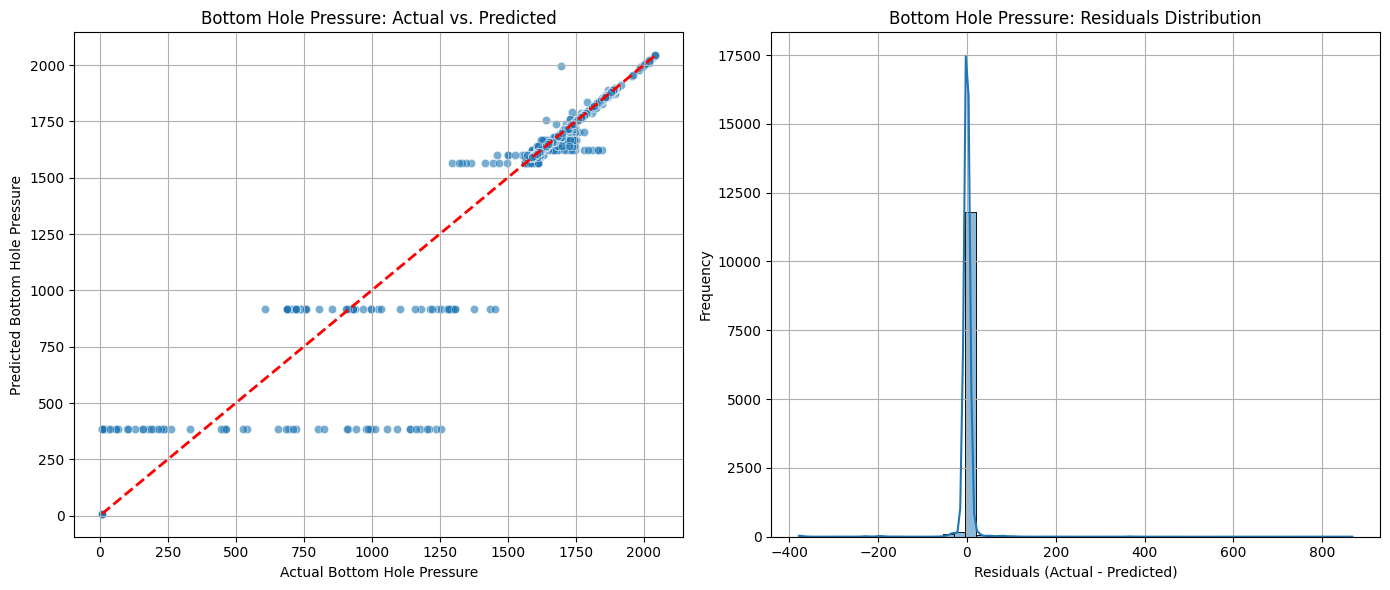

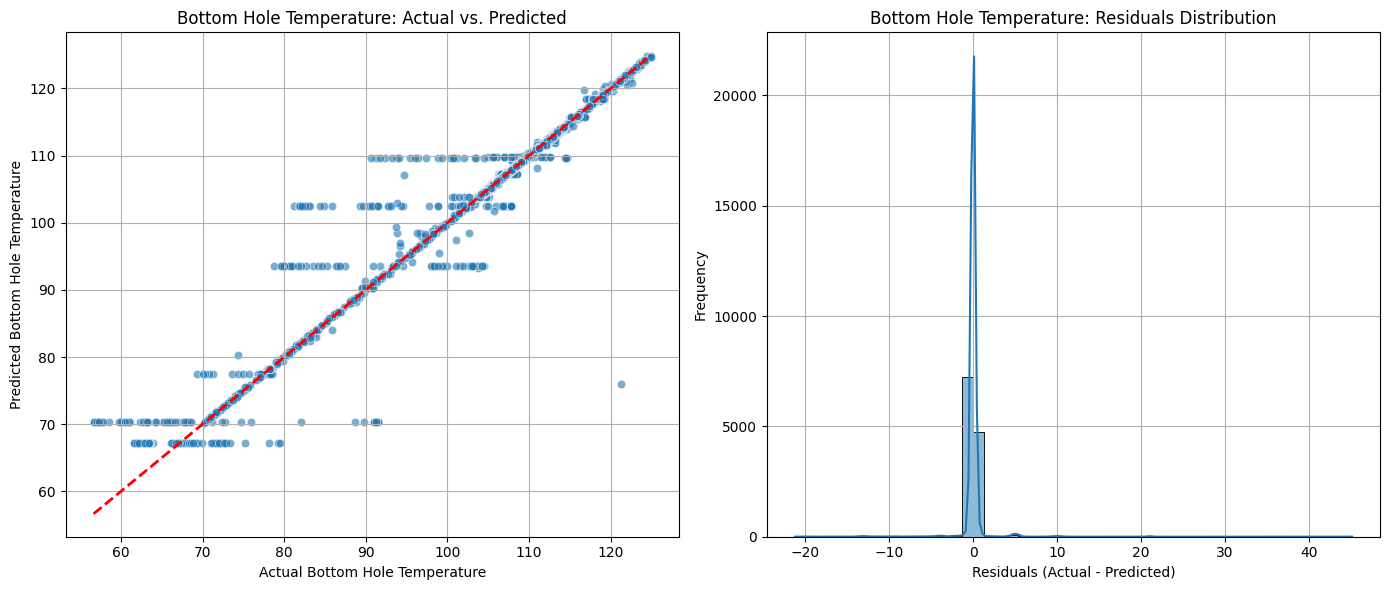

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Plot for Bottom Hole Pressure ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_pressure, y=y_pred_pressure_best, alpha=0.6)
plt.plot([y_test_pressure.min(), y_test_pressure.max()], [y_test_pressure.min(), y_test_pressure.max()], 'r--', lw=2)
plt.title('Bottom Hole Pressure: Actual vs. Predicted')
plt.xlabel('Actual Bottom Hole Pressure')
plt.ylabel('Predicted Bottom Hole Pressure')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.histplot(y_test_pressure - y_pred_pressure_best, kde=True, bins=50)
plt.title('Bottom Hole Pressure: Residuals Distribution')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)

plt.tight_layout()
plt.show()

# --- Plot for Bottom Hole Temperature ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test_temp, y=y_pred_temp_best, alpha=0.6)
plt.plot([y_test_temp.min(), y_test_temp.max()], [y_test_temp.min(), y_test_temp.max()], 'r--', lw=2)
plt.title('Bottom Hole Temperature: Actual vs. Predicted')
plt.xlabel('Actual Bottom Hole Temperature')
plt.ylabel('Predicted Bottom Hole Temperature')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.histplot(y_test_temp - y_pred_temp_best, kde=True, bins=50)
plt.title('Bottom Hole Temperature: Residuals Distribution')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)

plt.tight_layout()
plt.show()

## Predicted vs. Actual Data Over Time

To further visualize the model's performance, let's plot the actual and predicted values for `bottom_hole_pressure` and `bottom_hole_temperature` against `date__and__time` for the test set.

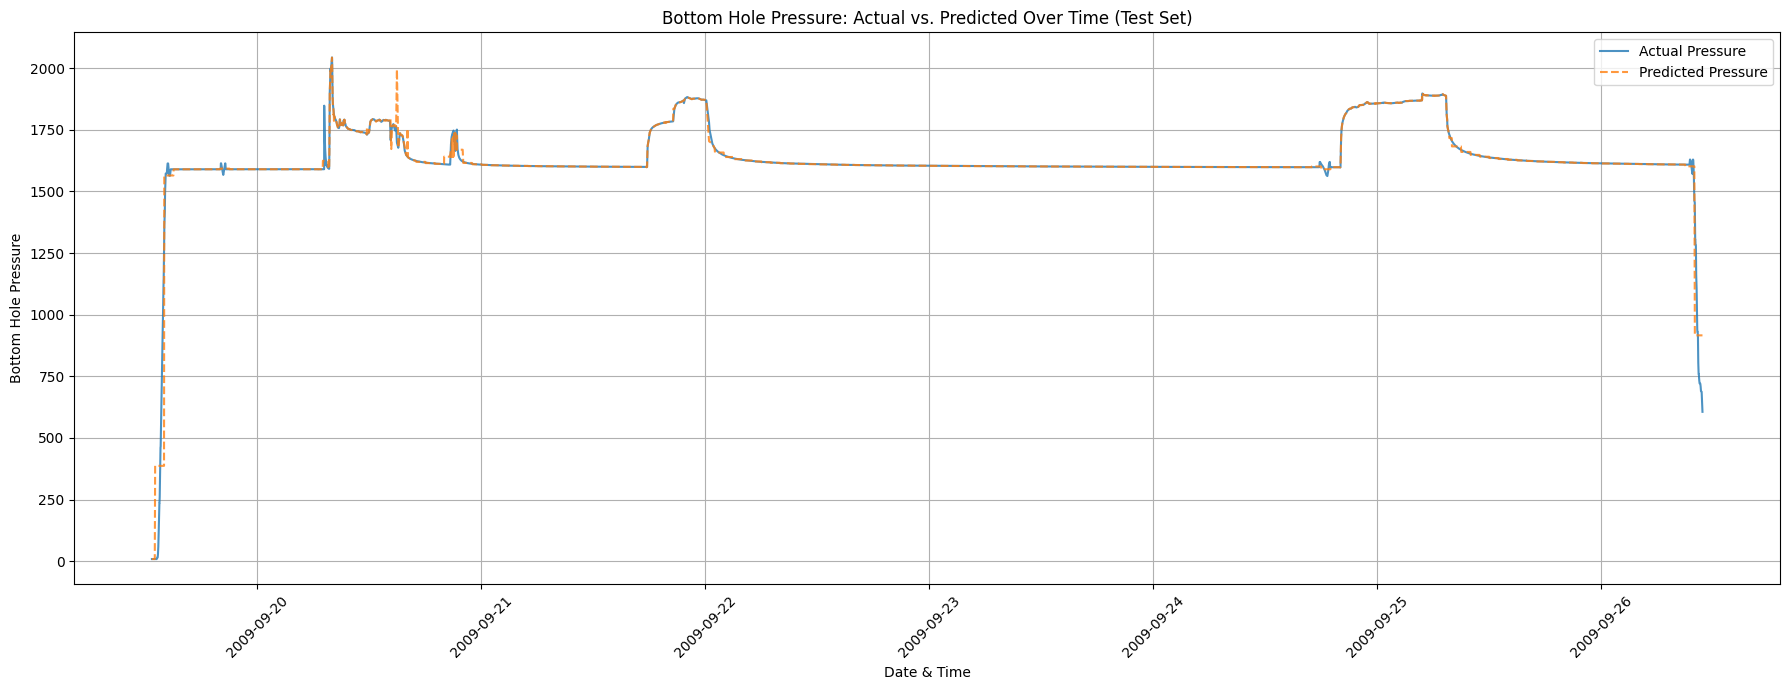

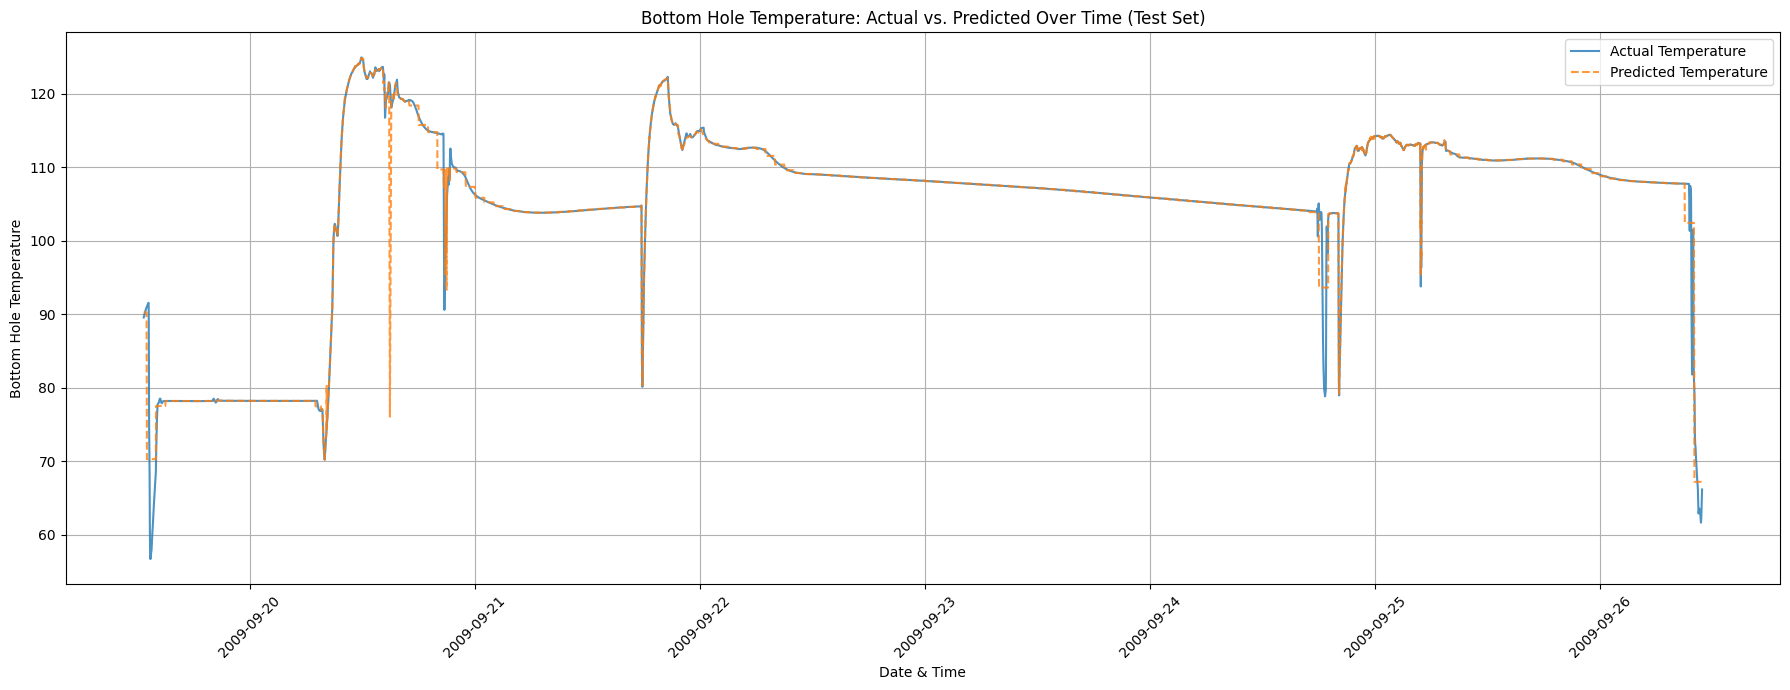

In [ ]:
# Get the 'date__and__time' for the test set. X_test_pressure (or X_test_temp) contains the original indices.
# We need to ensure that the 'date__and__time' aligns correctly with the shuffled y_test and y_pred values.
# A simple way is to reset the index of y_test and create a DataFrame for plotting.

# Create a DataFrame for pressure plotting
plot_df_pressure = pd.DataFrame({
    'date__and__time': df_processed.loc[y_test_pressure.index, 'date__and__time'],
    'Actual Pressure': y_test_pressure,
    'Predicted Pressure': y_pred_pressure_best
}).sort_values('date__and__time')

# Create a DataFrame for temperature plotting
plot_df_temperature = pd.DataFrame({
    'date__and__time': df_processed.loc[y_test_temp.index, 'date__and__time'],
    'Actual Temperature': y_test_temp,
    'Predicted Temperature': y_pred_temp_best
}).sort_values('date__and__time')

# --- Plot for Bottom Hole Pressure over time ---
plt.figure(figsize=(18, 7))
sns.lineplot(x='date__and__time', y='Actual Pressure', data=plot_df_pressure, label='Actual Pressure', alpha=0.8)
sns.lineplot(x='date__and__time', y='Predicted Pressure', data=plot_df_pressure, label='Predicted Pressure', alpha=0.8, linestyle='--')
plt.title('Bottom Hole Pressure: Actual vs. Predicted Over Time (Test Set)')
plt.xlabel('Date & Time')
plt.ylabel('Bottom Hole Pressure')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Plot for Bottom Hole Temperature over time ---
plt.figure(figsize=(18, 7))
sns.lineplot(x='date__and__time', y='Actual Temperature', data=plot_df_temperature, label='Actual Temperature', alpha=0.8)
sns.lineplot(x='date__and__time', y='Predicted Temperature', data=plot_df_temperature, label='Predicted Temperature', alpha=0.8, linestyle='--')
plt.title('Bottom Hole Temperature: Actual vs. Predicted Over Time (Test Set)')
plt.xlabel('Date & Time')
plt.ylabel('Bottom Hole Temperature')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature Importance Analysis

Now, let's identify the most influential features for predicting `bottom_hole_pressure` and `bottom_hole_temperature` using the Random Forest models. Feature importance helps us understand which input variables contributed most to the model's predictions.

/tmp/ipykernel_2482/1100301917.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df_pressure, palette='viridis')


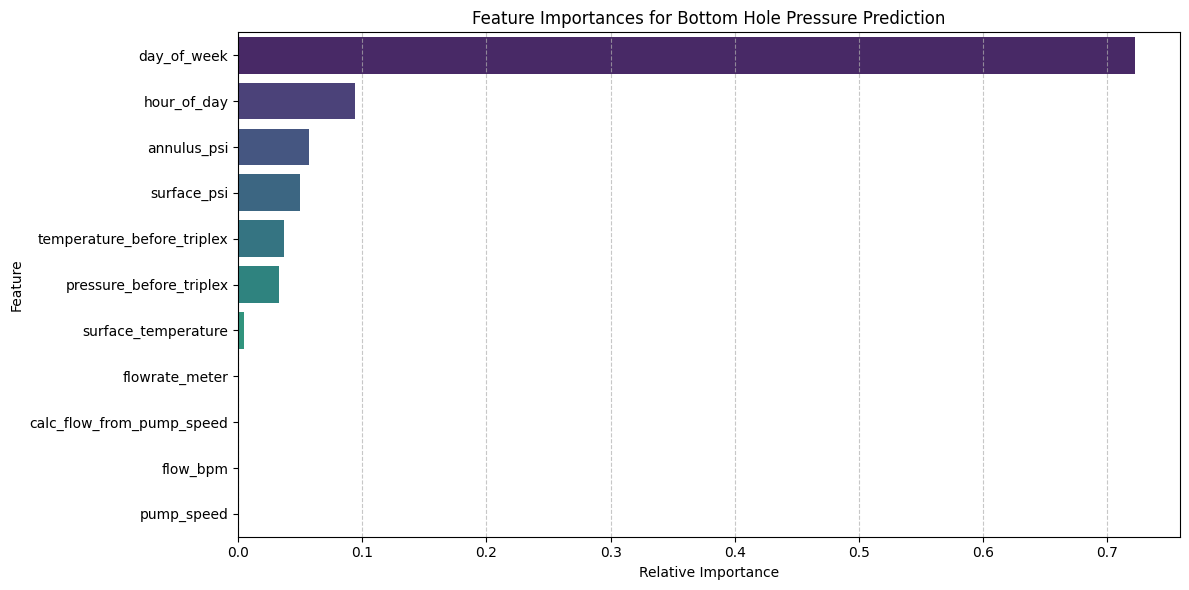

/tmp/ipykernel_2482/1100301917.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df_temp, palette='magma')


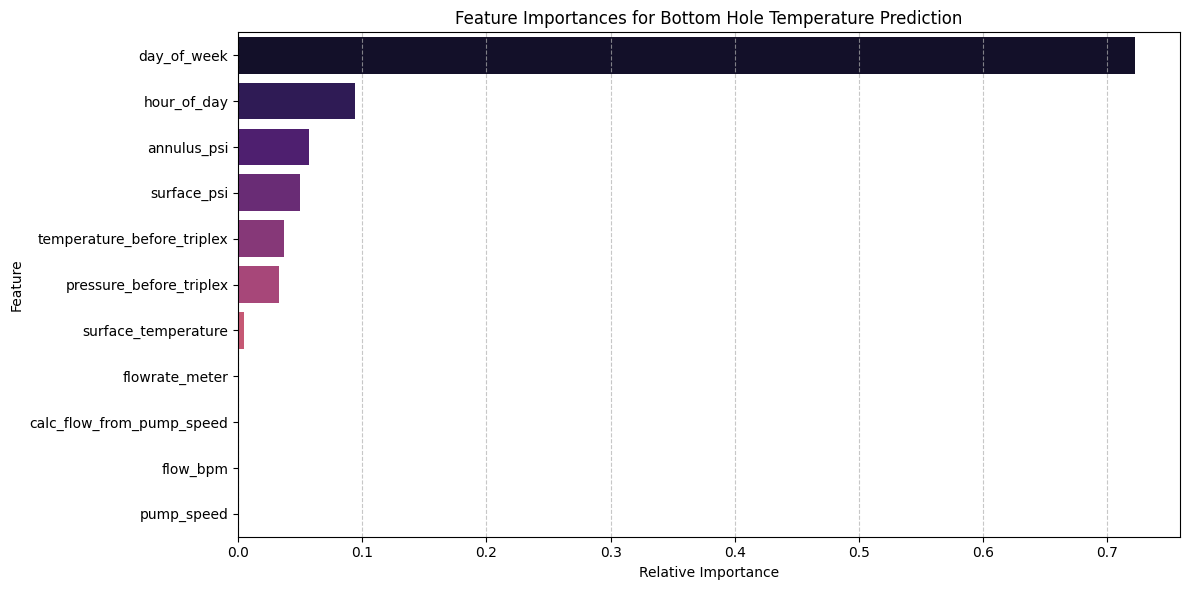

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances for Bottom Hole Pressure model
feature_importances_pressure = best_pressure_model.feature_importances_
features_df_pressure = pd.DataFrame({
    'Feature': X_train_pressure.columns,
    'Importance': feature_importances_pressure
}).sort_values(by='Importance', ascending=False)

# Get feature importances for Bottom Hole Temperature model
feature_importances_temp = best_temp_model.feature_importances_
features_df_temp = pd.DataFrame({
    'Feature': X_train_temp.columns,
    'Importance': feature_importances_temp
}).sort_values(by='Importance', ascending=False)

# --- Plotting Feature Importances for Pressure ---
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=features_df_pressure, palette='viridis')
plt.title('Feature Importances for Bottom Hole Pressure Prediction')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Plotting Feature Importances for Temperature ---
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=features_df_temp, palette='magma')
plt.title('Feature Importances for Bottom Hole Temperature Prediction')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Time-Series Cross-Validation

Given the sequential nature of our data, a standard random train-test split might lead to an overly optimistic evaluation. We'll use `TimeSeriesSplit` to perform a more appropriate cross-validation, ensuring that the training data always precedes the validation data chronologically.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor

# Initialize TimeSeriesSplit
# n_splits determines the number of splits. For example, 5 splits means 5 train/test folds.
tscv = TimeSeriesSplit(n_splits=5)

# --- Time-Series Cross-Validation for Bottom Hole Pressure ---
print("\n--- Time-Series Cross-Validation for Bottom Hole Pressure ---")
pressure_mae_scores = []
pressure_rmse_scores = []
pressure_r2_scores = []

for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y_pressure.iloc[train_index], y_pressure.iloc[test_index]

    # Instantiate a fresh model for each fold
    fold_pressure_model = RandomForestRegressor(random_state=42, n_jobs=-1) # Re-instantiate

    # Train the model
    fold_pressure_model.fit(X_train, y_train)
    y_pred_pressure_ts = fold_pressure_model.predict(X_test)

    # Evaluate
    mae = mean_absolute_error(y_test, y_pred_pressure_ts)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_pressure_ts))
    r2 = r2_score(y_test, y_pred_pressure_ts)

    pressure_mae_scores.append(mae)
    pressure_rmse_scores.append(rmse)
    pressure_r2_scores.append(r2)

    print(f"Fold {fold+1}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}")

print(f"\nAverage Pressure MAE: {np.mean(pressure_mae_scores):.2f}")
print(f"Average Pressure RMSE: {np.mean(pressure_rmse_scores):.2f}")
print(f"Average Pressure R2: {np.mean(pressure_r2_scores):.2f}")

# --- Time-Series Cross-Validation for Bottom Hole Temperature ---
print("\n--- Time-Series Cross-Validation for Bottom Hole Temperature ---")
temp_mae_scores = []
temp_rmse_scores = []
temp_r2_scores = []

for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y_temperature.iloc[train_index], y_temperature.iloc[test_index]

    # Instantiate a fresh model for each fold
    fold_temp_model = RandomForestRegressor(random_state=42, n_jobs=-1) # Re-instantiate

    # Train the model
    fold_temp_model.fit(X_train, y_train)
    y_pred_temp_ts = fold_temp_model.predict(X_test)

    # Evaluate
    mae = mean_absolute_error(y_test, y_pred_temp_ts)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_temp_ts))
    r2 = r2_score(y_test, y_pred_temp_ts)

    temp_mae_scores.append(mae)
    temp_rmse_scores.append(rmse)
    temp_r2_scores.append(r2)

    print(f"Fold {fold+1}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}")

print(f"\nAverage Temperature MAE: {np.mean(temp_mae_scores):.2f}")
print(f"Average Temperature RMSE: {np.mean(temp_rmse_scores):.2f}")
print(f"Average Temperature R2: {np.mean(temp_r2_scores):.2f}")


--- Time-Series Cross-Validation for Bottom Hole Pressure ---
Fold 1: MAE=883.99, RMSE=1153.79, R2=-180.87
Fold 2: MAE=36.98, RMSE=46.44, R2=-12.83
Fold 3: MAE=4.72, RMSE=5.41, R2=-23.40
Fold 4: MAE=13.78, RMSE=21.40, R2=0.97
Fold 5: MAE=383.75, RMSE=593.43, R2=-16.18

Average Pressure MAE: 264.64
Average Pressure RMSE: 364.09
Average Pressure R2: -46.46

--- Time-Series Cross-Validation for Bottom Hole Temperature ---
Fold 1: MAE=16.95, RMSE=19.07, R2=-10.08
Fold 2: MAE=2.18, RMSE=2.93, R2=-1.66
Fold 3: MAE=2.06, RMSE=2.25, R2=-5.69
Fold 4: MAE=2.64, RMSE=5.17, R2=0.38
Fold 5: MAE=11.02, RMSE=12.62, R2=-1.61

Average Temperature MAE: 6.97
Average Temperature RMSE: 8.41
Average Temperature R2: -3.73


## Visualizing Time-Series Cross-Validation Splits

To understand the poor performance in some of the cross-validation folds, let's visualize how the `TimeSeriesSplit` divides the data. This will help us identify if the model is being trained or tested on unusual data segments (e.g., long periods of zero values or non-recording times) that could explain the low R2 scores.

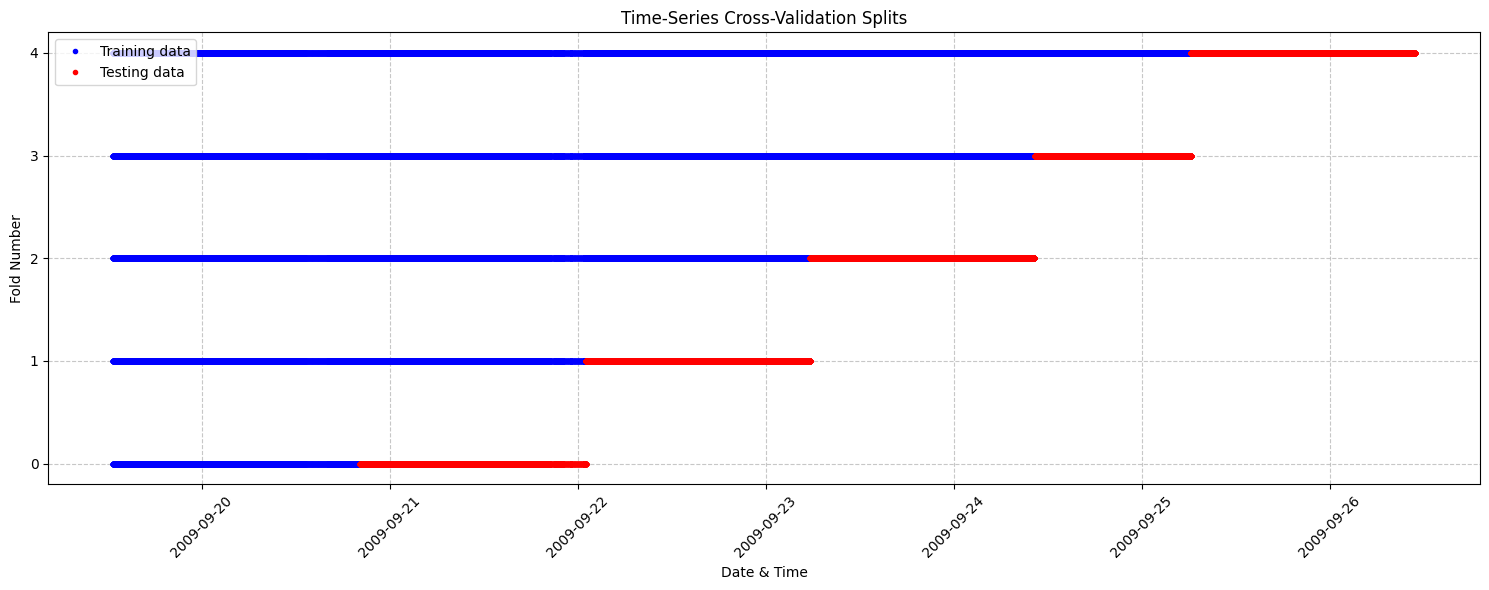

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 6))

# Create a simple array representing the time index
time_indices = np.arange(len(df_processed))

# Get the actual 'date__and__time' column to plot against
full_dates = df_processed['date__and__time']

for i, (train_index, test_index) in enumerate(tscv.split(X)):
    # Plot training periods
    ax.plot(full_dates.iloc[train_index], np.full_like(train_index, i),
            'o', markersize=3, label='Training data' if i == 0 else '', color='blue')
    # Plot testing periods
    ax.plot(full_dates.iloc[test_index], np.full_like(test_index, i),
            'o', markersize=3, label='Testing data' if i == 0 else '', color='red')

ax.set_title('Time-Series Cross-Validation Splits')
ax.set_xlabel('Date & Time')
ax.set_ylabel('Fold Number')
ax.legend(loc='upper left')
ax.set_yticks(np.arange(tscv.n_splits))
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Re-running Time-Series Cross-Validation with Filtered Data

As discussed, the poor performance in some initial cross-validation folds was due to training and testing on zero-filled non-recording periods. To address this, I will now filter the `df_processed` DataFrame to include only the rows where `is_recording` is `True`. This ensures that our cross-validation is performed solely on actual operational data.

After filtering, I will redefine the features (`X_filtered`) and target variables (`y_pressure_filtered`, `y_temperature_filtered`) using this new dataset. Then, I will re-run the `TimeSeriesSplit` with these filtered variables to obtain a more accurate and representative evaluation of the model's performance on active recording periods.

In [ ]:
# Filter the DataFrame to include only recording periods
df_filtered = df_processed[df_processed['is_recording']].copy()

print("Filtered DataFrame head:")
display(df_filtered.head())
print("Filtered DataFrame info:")
display(df_filtered.info())

# Redefine features (X_filtered) and target variables (y_pressure_filtered, y_temperature_filtered) using the filtered DataFrame
X_filtered = df_filtered.drop(columns=[
    'date', 'time', 'date__and__time',
    'bottom_hole_pressure', 'corrected_bottom_hole_pressure', 'bottom_hole_temperature',
    'is_recording', 'flowmeter_issue_period'
])
y_pressure_filtered = df_filtered['bottom_hole_pressure']
y_temperature_filtered = df_filtered['bottom_hole_temperature']

print("Shape of X_filtered:", X_filtered.shape)
print("Shape of y_pressure_filtered:", y_pressure_filtered.shape)
print("Shape of y_temperature_filtered:", y_temperature_filtered.shape)

Filtered DataFrame head:


,date,time,date__and__time,bottom_hole_pressure,corrected_bottom_hole_pressure,bottom_hole_temperature,surface_temperature,surface_psi,annulus_psi,flowrate_meter,pump_speed,calc_flow_from_pump_speed,flow_bpm,temperature_before_triplex,pressure_before_triplex,is_recording,flowmeter_issue_period,hour_of_day,day_of_week
6805,2009-09-20 07:34:53,2009-09-20 07:34:53,2009-09-20 07:34:53,1593.967,1593.967,76.99504,62.0,305.0,6.0,0.0,0.0,0.0,0.0,55.0,308.0,True,False,7,6
6806,2009-09-20 07:35:00,2009-09-20 07:35:00,2009-09-20 07:35:00,1593.967,1593.967,76.99504,62.0,304.0,6.0,0.0,0.0,0.0,0.0,55.0,308.0,True,False,7,6
6807,2009-09-20 07:35:07,2009-09-20 07:35:07,2009-09-20 07:35:07,1593.930,1593.930,76.99989,62.0,306.0,6.0,0.0,0.0,0.0,0.0,55.0,308.0,True,False,7,6
6808,2009-09-20 07:35:14,2009-09-20 07:35:14,2009-09-20 07:35:14,1593.835,1593.835,76.99796,62.0,305.0,6.0,0.0,0.0,0.0,0.0,55.0,308.0,True,False,7,6
6809,2009-09-20 07:35:21,2009-09-20 07:35:21,2009-09-20 07:35:21,1593.766,1593.766,76.99796,62.0,304.0,6.0,0.0,0.0,0.0,0.0,55.0,308.0,True,False,7,6


Filtered DataFrame info:
<class 'pandas.core.frame.DataFrame'>
Index: 12432 entries, 6805 to 52093
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   date                            12432 non-null  datetime64[ns]
 1   time                            12432 non-null  object        
 2   date__and__time                 12432 non-null  datetime64[ns]
 3   bottom_hole_pressure            12432 non-null  float64       
 4   corrected_bottom_hole_pressure  12432 non-null  float64       
 5   bottom_hole_temperature         12432 non-null  float64       
 6   surface_temperature             12432 non-null  float64       
 7   surface_psi                     12432 non-null  float64       
 8   annulus_psi                     12432 non-null  float64       
 9   flowrate_meter                  12432 non-null  float64       
 10  pump_speed                      12432 non-null 

None

Shape of X_filtered: (12432, 11)
Shape of y_pressure_filtered: (12432,)
Shape of y_temperature_filtered: (12432,)


In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.ensemble import RandomForestRegressor

# Initialize TimeSeriesSplit for the filtered data
tscv_filtered = TimeSeriesSplit(n_splits=5)

# --- Time-Series Cross-Validation for Bottom Hole Pressure (Filtered Data) ---
print("\n--- Time-Series Cross-Validation for Bottom Hole Pressure (Filtered Data) ---")
pressure_mae_scores_filtered = []
pressure_rmse_scores_filtered = []
pressure_r2_scores_filtered = []

for fold, (train_index, test_index) in enumerate(tscv_filtered.split(X_filtered)):
    X_train_filtered, X_test_filtered = X_filtered.iloc[train_index], X_filtered.iloc[test_index]
    y_train_pressure_filtered, y_test_pressure_filtered = y_pressure_filtered.iloc[train_index], y_pressure_filtered.iloc[test_index]

    fold_pressure_model_filtered = RandomForestRegressor(random_state=42, n_jobs=-1)
    fold_pressure_model_filtered.fit(X_train_filtered, y_train_pressure_filtered)
    y_pred_pressure_ts_filtered = fold_pressure_model_filtered.predict(X_test_filtered)

    mae = mean_absolute_error(y_test_pressure_filtered, y_pred_pressure_ts_filtered)
    rmse = np.sqrt(mean_squared_error(y_test_pressure_filtered, y_pred_pressure_ts_filtered))
    r2 = r2_score(y_test_pressure_filtered, y_pred_pressure_ts_filtered)

    pressure_mae_scores_filtered.append(mae)
    pressure_rmse_scores_filtered.append(rmse)
    pressure_r2_scores_filtered.append(r2)

    print(f"Fold {fold+1}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}")

print(f"\nAverage Pressure MAE (Filtered): {np.mean(pressure_mae_scores_filtered):.2f}")
print(f"Average Pressure RMSE (Filtered): {np.mean(pressure_rmse_scores_filtered):.2f}")
print(f"Average Pressure R2 (Filtered): {np.mean(pressure_r2_scores_filtered):.2f}")

# --- Time-Series Cross-Validation for Bottom Hole Temperature (Filtered Data) ---
print("\n--- Time-Series Cross-Validation for Bottom Hole Temperature (Filtered Data) ---")
temp_mae_scores_filtered = []
temp_rmse_scores_filtered = []
temp_r2_scores_filtered = []

for fold, (train_index, test_index) in enumerate(tscv_filtered.split(X_filtered)):
    X_train_filtered, X_test_filtered = X_filtered.iloc[train_index], X_filtered.iloc[test_index]
    y_train_temp_filtered, y_test_temp_filtered = y_temperature_filtered.iloc[train_index], y_temperature_filtered.iloc[test_index]

    fold_temp_model_filtered = RandomForestRegressor(random_state=42, n_jobs=-1)
    fold_temp_model_filtered.fit(X_train_filtered, y_train_temp_filtered)
    y_pred_temp_ts_filtered = fold_temp_model_filtered.predict(X_test_filtered)

    mae = mean_absolute_error(y_test_temp_filtered, y_pred_temp_ts_filtered)
    rmse = np.sqrt(mean_squared_error(y_test_temp_filtered, y_pred_temp_ts_filtered))
    r2 = r2_score(y_test_temp_filtered, y_pred_temp_ts_filtered)

    temp_mae_scores_filtered.append(mae)
    temp_rmse_scores_filtered.append(rmse)
    temp_r2_scores_filtered.append(r2)

    print(f"Fold {fold+1}: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}")

print(f"\nAverage Temperature MAE (Filtered): {np.mean(temp_mae_scores_filtered):.2f}")
print(f"Average Temperature RMSE (Filtered): {np.mean(temp_rmse_scores_filtered):.2f}")
print(f"Average Temperature R2 (Filtered): {np.mean(temp_r2_scores_filtered):.2f}")


--- Time-Series Cross-Validation for Bottom Hole Pressure (Filtered Data) ---
Fold 1: MAE=61.22, RMSE=78.30, R2=0.04
Fold 2: MAE=22.38, RMSE=34.74, R2=0.87
Fold 3: MAE=9.26, RMSE=10.59, R2=-2.15
Fold 4: MAE=9.46, RMSE=15.08, R2=-15.51
Fold 5: MAE=18.08, RMSE=21.35, R2=0.30

Average Pressure MAE (Filtered): 24.08
Average Pressure RMSE (Filtered): 32.01
Average Pressure R2 (Filtered): -3.29

--- Time-Series Cross-Validation for Bottom Hole Temperature (Filtered Data) ---
Fold 1: MAE=8.56, RMSE=12.11, R2=-0.63
Fold 2: MAE=12.14, RMSE=18.74, R2=-3.78
Fold 3: MAE=2.13, RMSE=2.32, R2=-4.48
Fold 4: MAE=0.59, RMSE=0.77, R2=-0.67
Fold 5: MAE=1.27, RMSE=3.38, R2=-0.27

Average Temperature MAE (Filtered): 4.94
Average Temperature RMSE (Filtered): 7.46
Average Temperature R2 (Filtered): -1.97


## Visualizing Filtered Time-Series Cross-Validation Splits

To further diagnose the performance, especially the negative R2 scores in some folds even after filtering, let's visualize how the `TimeSeriesSplit` divides the *filtered* data. This will help us observe if certain folds still encounter periods that are challenging for the model, such as very short training sets or specific data characteristics within the active recording periods.

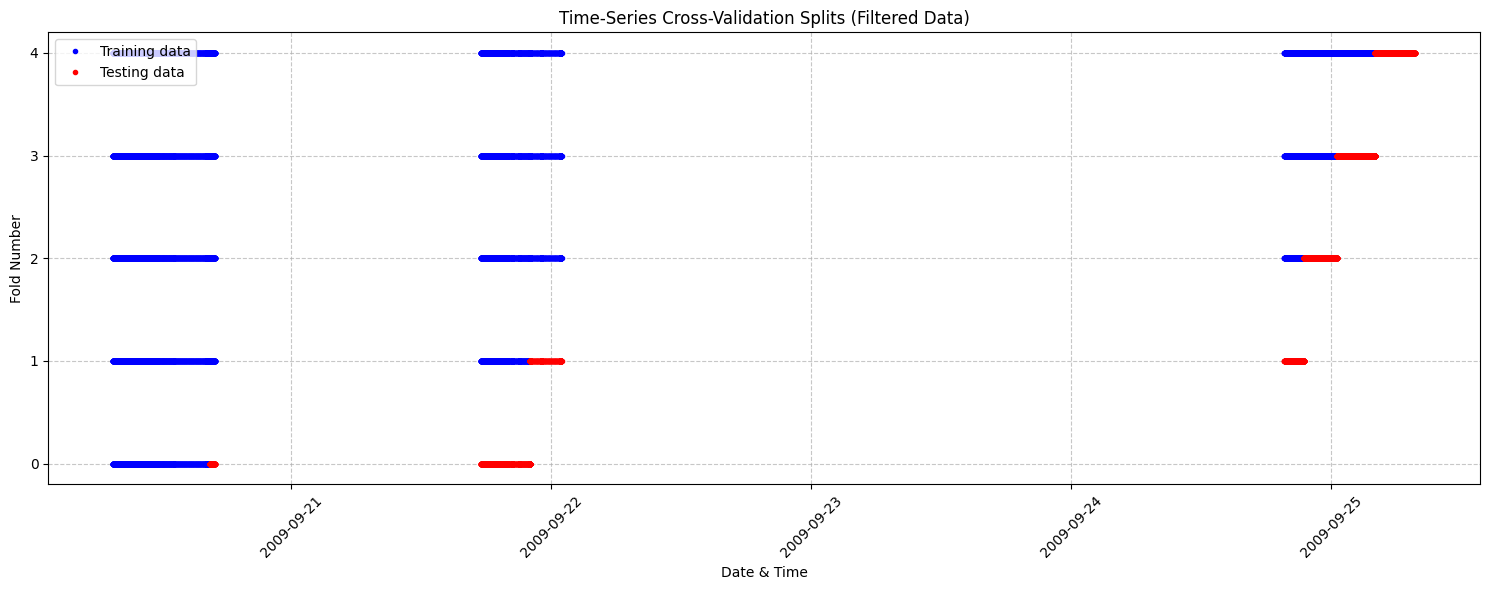

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 6))

# Get the actual 'date__and__time' column from the filtered DataFrame to plot against
full_dates_filtered = df_filtered['date__and__time']

for i, (train_index, test_index) in enumerate(tscv_filtered.split(X_filtered)):
    # Plot training periods
    ax.plot(full_dates_filtered.iloc[train_index], np.full_like(train_index, i),
            'o', markersize=3, label='Training data' if i == 0 else '', color='blue')
    # Plot testing periods
    ax.plot(full_dates_filtered.iloc[test_index], np.full_like(test_index, i),
            'o', markersize=3, label='Testing data' if i == 0 else '', color='red')

ax.set_title('Time-Series Cross-Validation Splits (Filtered Data)')
ax.set_xlabel('Date & Time')
ax.set_ylabel('Fold Number')
ax.legend(loc='upper left')
ax.set_yticks(np.arange(tscv_filtered.n_splits))
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()